# Context-length ablation

Turns the tables written by `run.py` (`results/<dataset>/context_length_<metric>.csv`)
into the paper figure. Each curve shows a model's error rate when it is given only the
first *N* words of every validation example, so a falling curve means longer context helps
and a flat one means the model has all the context it can use.

Figures are written to `figures/`, next to this notebook.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import FixedLocator, ScalarFormatter

# Shared paper-figure style (matches the other notebooks under tnqeet/notebooks/).
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "font.size": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 20,
    "axes.labelweight": "bold",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [2]:
def find_repo_root(start=None):
    """Walk up from the kernel's cwd to the directory holding pyproject.toml.

    Kernels start either at the repo root or next to the notebook depending on
    how the notebook is launched, so paths are anchored here rather than on cwd.
    """
    path = os.path.abspath(start or os.getcwd())
    while not os.path.exists(os.path.join(path, "pyproject.toml")):
        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("could not locate the repository root from " + os.getcwd())
        path = parent
    return path


REPO_ROOT = find_repo_root()
EXPERIMENT_DIR = os.path.join(REPO_ROOT, "tnqeet_scripts", "context_length_experiment")
RESULTS_DIR = os.path.join(EXPERIMENT_DIR, "results", "val_dataset")
FIGURES_DIR = os.path.join(EXPERIMENT_DIR, "notebooks", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Same palette and legend names as the other model-comparison figures.
METHOD_PALETTE = {
    "8-gram":          "#B45309",  # amber
    "BiLSTM 6L":       "#0F766E",  # teal
    "Transformer 12L": "#7C3AED",  # purple
    "CANINE canine-s": "#0EA5E9",  # sky
}
LEGEND_NAMES = {
    "8-gram":          "N-gram",
    "BiLSTM 6L":       "LSTM",
    "Transformer 12L": "Transformer",
    "CANINE canine-s": "CANINE",
}
PLOT_ORDER = list(METHOD_PALETTE)
METRIC_LABELS = {"wer": "WER", "cer": "CER", "doter": "DotER"}

# Log-spaced subset of the swept context lengths; labelling all 15 would crowd the axis.
XTICKS = [1, 2, 3, 5, 10, 20, 50, 100, 300, 1000]

# A model counts as saturated once it is within this many points of its own best score.
SATURATION_TOL = 0.3

In [3]:
def load(metric):
    """Read one metric's table, e.g. context_length_wer.csv."""
    df = pd.read_csv(os.path.join(RESULTS_DIR, f"context_length_{metric}.csv"))
    df.columns = [c.strip() for c in df.columns]
    return df


def saturation_point(df):
    """First context length at which every model is within SATURATION_TOL of its floor."""
    x = df["ctx words"].to_numpy()
    gaps = np.vstack([df[m].to_numpy() - df[m].min() for m in PLOT_ORDER])
    saturated = (gaps <= SATURATION_TOL).all(axis=0)
    return int(x[np.argmax(saturated)]) if saturated.any() else None


load("wer")

,ctx words,#samples,8-gram,BiLSTM 6L,Transformer 12L,CANINE canine-s
0,1,1124,10.68,13.26,28.20,32.83
1,2,1193,6.58,10.23,13.12,23.64
2,3,1198,5.70,9.29,10.68,18.34
3,5,1200,5.93,8.62,8.12,13.22
4,8,1200,5.93,7.03,6.36,9.90
5,10,1200,5.89,6.88,5.68,8.21
6,20,1200,5.82,5.90,4.41,5.83
7,30,1200,5.84,5.59,4.23,5.21
8,50,1200,5.84,5.43,4.13,4.81
9,80,1200,5.83,5.38,4.07,4.62


In [4]:
def plot_context_curves(metric, save=True):
    df = load(metric)
    x = df["ctx words"].to_numpy()
    label = METRIC_LABELS[metric]

    fig, ax = plt.subplots(figsize=(10.0, 4.8))
    fig.patch.set_facecolor("white")

    # Mark where the curves flatten, computed rather than eyeballed.
    knee = saturation_point(df)
    if knee is not None:
        ax.axvline(knee, color="#9CA3AF", linestyle=":", linewidth=2.0, zorder=1)
        ax.annotate(
            f"saturates at\n{knee} words",
            xy=(knee * 1.25, df[PLOT_ORDER].to_numpy().max() * 0.72),
            fontsize=16, color="#4B5563", ha="left", va="center",
        )

    for method in PLOT_ORDER:
        ax.plot(
            x, df[method].to_numpy(),
            marker="o", markersize=9, linewidth=3.0,
            color=METHOD_PALETTE[method], label=LEGEND_NAMES[method], zorder=3,
        )

    ax.set_xscale("log")
    ax.xaxis.set_major_locator(FixedLocator(XTICKS))
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.xaxis.set_minor_locator(FixedLocator([]))
    ax.set_xlim(x.min() * 0.9, x.max() * 1.1)
    ax.set_xlabel("Context length (words)", labelpad=10)
    ax.set_ylabel(f"{label} (%)", labelpad=10)
    ax.set_ylim(0, df[PLOT_ORDER].to_numpy().max() * 1.06)

    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.4, color="#9CA3AF")
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", which="both", length=0, colors="#4B5563", pad=4)
    ax.legend(
        loc="lower center", bbox_to_anchor=(0.5, 1.02), ncol=len(PLOT_ORDER),
        frameon=False, handletextpad=0.5, columnspacing=1.8,
    )

    fig.tight_layout()
    if save:
        plt.savefig(
            os.path.join(FIGURES_DIR, f"dotting_{metric}_by_context_length.pdf"),
            bbox_inches="tight",
        )
    return fig

## The paper figure (WER)

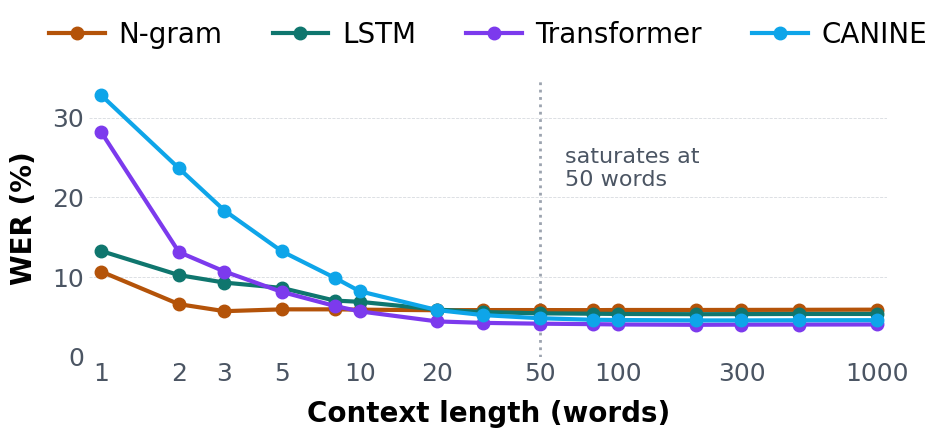

In [8]:
plot_context_curves("wer")
plt.show()

## The same view for the other two metrics

Kept for reference; the paper reports the WER panel.

In [ ]:
for metric in ("cer", "doter"):
    plot_context_curves(metric)
    plt.show()

Note that the shortest prefixes are scored on slightly fewer examples
(1,124 at one word against 1,200 from five words on), since `run.py` skips prefixes that
contain no ambiguous *rasm* and therefore have nothing to restore. The `#samples`
column of each CSV records this.